# Phase 1: Exploratory Data Analysis (EDA)
**Goal:** Understand the dataset before touching any model.
We want to answer:
- What columns exist and what do they mean?
- How imbalanced is the dataset?
- What does the text look like? How long are descriptions?
- Are there missing values we need to handle?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/fake_job_postings.csv')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head(3)

Shape: (17880, 18)

Column names: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## 1.1 — Class Distribution
The target column is `fraudulent`: 0 = real, 1 = fake.

**Why this matters:** If 95% of rows are real, a model that always predicts 'real' gets 95% accuracy — but detects zero fakes. That's useless. This is called the **class imbalance problem**.

Class counts:
  Real (0): 17,014  (95.2%)
  Fake (1): 866  (4.8%)


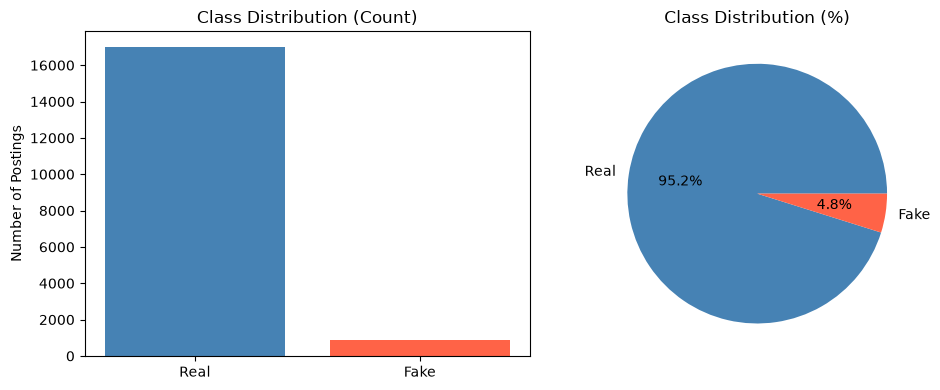

In [3]:
counts = df['fraudulent'].value_counts()
print('Class counts:')
print(f"  Real (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Fake (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Real', 'Fake'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Number of Postings')

# Pie chart
axes[1].pie([counts[0], counts[1]], labels=['Real', 'Fake'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%')
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()

## 1.2 — Missing Values
Real-world data is messy. We need to know which columns have gaps before deciding what to use as model input.

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                     Missing Count  Missing %
salary_range                 15012       84.0
department                   11547       64.6
required_education            8105       45.3
benefits                      7212       40.3
required_experience           7050       39.4
function                      6455       36.1
industry                      4903       27.4
employment_type               3471       19.4
company_profile               3308       18.5
requirements                  2696       15.1
location                       346        1.9
description                      1        0.0


## 1.3 — Text Length Distribution
DistilBERT has a **512 token limit**. If job descriptions are often longer, we're truncating text and losing information.

Tokens ≈ words * 1.3 (rough estimate). So 512 tokens ≈ ~390 words.

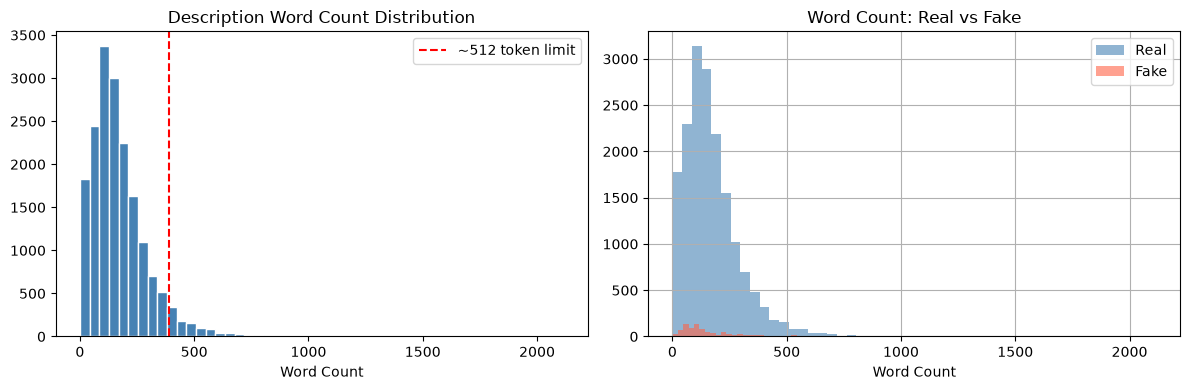


Descriptions exceeding ~512 tokens: 930 (5.2%)


In [5]:
# Fill NaN with empty string for length analysis
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in text_cols:
    df[col] = df[col].fillna('')

# Word count of the description column
df['desc_word_count'] = df['description'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(df['desc_word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(390, color='red', linestyle='--', label='~512 token limit')
axes[0].set_title('Description Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].legend()

# Real vs Fake
df[df['fraudulent']==0]['desc_word_count'].hist(ax=axes[1], bins=50,
    alpha=0.6, color='steelblue', label='Real')
df[df['fraudulent']==1]['desc_word_count'].hist(ax=axes[1], bins=50,
    alpha=0.6, color='tomato', label='Fake')
axes[1].set_title('Word Count: Real vs Fake')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/text_length_distribution.png', dpi=150)
plt.show()

print(f"\nDescriptions exceeding ~512 tokens: "
      f"{(df['desc_word_count'] > 390).sum()} "
      f"({(df['desc_word_count'] > 390).mean()*100:.1f}%)")

## 1.4 — What Features Will We Use?
We'll combine multiple text columns into a single input string for DistilBERT.
Using more fields = more signal = better detection.

In [6]:
def combine_text(row):
    """Combine relevant text fields into one input string.
    
    We separate each field with a period so the tokenizer
    treats them as sentence boundaries.
    """
    parts = [
        row['title'],
        row['company_profile'],
        row['description'],
        row['requirements'],
        row['benefits']
    ]
    # Filter out empty strings, join with separator
    return ' . '.join([p for p in parts if p.strip()])

df['combined_text'] = df.apply(combine_text, axis=1)

# Preview
print('=== REAL JOB SAMPLE ===')
print(df[df['fraudulent']==0]['combined_text'].iloc[0][:500])
print('\n=== FAKE JOB SAMPLE ===')
print(df[df['fraudulent']==1]['combined_text'].iloc[0][:500])

=== REAL JOB SAMPLE ===
Marketing Intern . We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contribut

=== FAKE JOB SAMPLE ===
IC&E Technician .                                                                                  Staffing &amp; Recruiting done right for the Oil &amp; Energy Industry!Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant signing bonus by Refined Resources (in addition to any potential signing bonuses our clien

In [7]:
# Save the processed dataframe for use in the next notebook
df[['combined_text', 'fraudulent']].to_csv('../data/processed.csv', index=False)
print('Saved processed.csv — shape:', df.shape)

Saved processed.csv — shape: (17880, 20)
